## Introduction

In this notebook, a visualisation of Sentinel 3 data for Brussels, Belgium, is done. 

What to learn:

1. Using pystac to retrieve Sentinel 2 and Sentinel 3 data based on an intersection with a geometry (e.g. geojson file).
2. Using filters for Sentinel 2 based on a step-by-step approach and filter for:
    - cloud cover
    - Sentinel 2 tile
    - time period
    - data depreciated or not
3. Using filters for Sentinel 3:
    - sensor (S3A or S3B)
    - real time or 
5. How to clip Sentinel 2 and Sentinel 3 data based on a geometry (other than longitude and longitude)
7. Compute Normalised Difference Vegetation Index (NDVI) and Land Surface Temperature (LST)
8. Visualisation of NDVI and LST
9. Interactive visualisation using the Folium library
10. Dask

## Reading in the Python libraries

In [301]:
!pip install folium mapclassify --quiet

In [302]:
import folium
import matplotlib.pyplot as plt
import mapclassify
import geopandas as gpd
from distributed import LocalCluster
from pystac import Collection, MediaType
from pystac_client import Client
import xarray as xr

## Reading in the Area of Interest

Here, you can specifiy your file path for your Area of Interest (AOI) or upload your file for your region of interest.

In [306]:
## Please uncomment this line if you want to run this script from scratch
## brussels_file_path = 'https://github.com/EllenB/eopf/releases/download/data/brussels_dissolved.geojson'     

In [304]:
# !wget -O brussels_dissolved.geojson \
# $brussels_file_path

<Axes: >

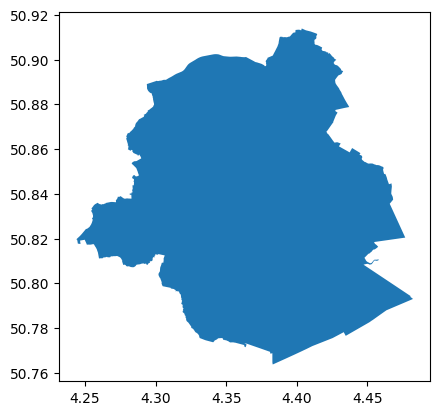

In [307]:
gdf = gpd.read_file('brussels_dissolved.geojson')
gdf.plot()

## Setting up a Dask cluster

In [308]:
cluster = LocalCluster()
client = cluster.get_client()
client

/opt/conda/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41941 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41941/status,
Dashboard: http://127.0.0.1:41941/status,Workers: 4
Total threads: 4,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45685,Workers: 0
Dashboard: http://127.0.0.1:41941/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46037,Total threads: 1
Dashboard: http://127.0.0.1:36423/status,Memory: 2.50 GiB
Nanny: tcp://127.0.0.1:38741,


## Defining the parameters

In [309]:
period = "2025-01-01/2026-03-08"
aoi = gdf.geometry.iloc[0].__geo_interface__

## NDVI

### Extracting the Sentinel 2 image

In [310]:
items_s2 = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    datetime=period
   ).item_collection()

/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UFS_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UES_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2A_MSIL2A_20251102T105231_N0511_R051_T31UFS_20251102T144301' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2B_MSIL2A_20251102T104109_N0511_R008_T31UES_20251102T112516' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251031T105221_N0511_R051_T31UFS_20251031T144221' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The it

We notice a lot of warnings above and these are data are actually deprecated. Below, we will show how to deal with them.

In [311]:
print(f'There are {len(items_s2)} items in the collection')

There are 223 items in the collection


In [312]:
for item in items_s2[0:10]:
    print(item)

<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UFS_20260307T161311>
<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UES_20260307T161311>
<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UFS_20260305T144521>
<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UFS_20260302T161544>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544>
<Item id=S2C_MSIL2A_20260228T105001_N0512_R051_T31UFS_20260228T145912>
<Item id=S2C_MSIL2A_20260228T105001_N0512_R051_T31UES_20260228T145912>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UFS_20260225T144110>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UES_20260225T144110>


To learn a bit about the data, let's have a look at one data point:

In [313]:
item_s2 = items_s2[0]
item_s2

<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UFS_20260307T161311>

Expanding the above line, we can see things like the percentage cloud cover, the Sentinel 2 etc. Before proceeding, it would be good to see how the Sentinel 2 tiles look like with respect to our area of interest. To do so, we use the Folium Python library. More specifically, we notice that we have the following two tiles: 31UES and 31UFS. We put the stac results into a Geopandas dataframe:

In [180]:
type(items_s2)

pystac.item_collection.ItemCollection

In [181]:
# items_s2 = eopf_catalog.search(
#     collections='sentinel-2-l2a',
#     intersects=aoi,
#     datetime=period
#    )

In [315]:
# items = items_s2.get_all_items()
# items = items_s2.item_collection()

Next, we want to investigate the data a little bit more and have an overview of the data in general such as Sentinel 2 grid codes, cloud cover, etc. The idea is to plot and see in which Sentinel 2 tiles the AOI falls.  

In [314]:
## Based on code of:
## https://stacspec.org/en/tutorials/reading-stac-planetary-computer/
df = gpd.GeoDataFrame.from_features(items_s2.to_dict(), crs="epsg:4326")
df.head()

,geometry,gsd,created,mission,sci:doi,updated,datetime,platform,grid:code,proj:bbox,...,processing:version,product:timeliness,sat:absolute_orbit,sat:relative_orbit,view:sun_elevation,processing:facility,processing:software,eopf:instrument_mode,product:timeliness_category,sat:platform_international_designator
0,"POLYGON ((4.43705 51.38253, 4.46157 51.44192, ...",10.0,2026-03-07T20:23:58.515446Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-07T20:23:58.515446Z,2026-03-07T10:39:11.025000Z,sentinel-2c,MGRS-31UFS,"[4.408715109637645, 50.42629366061962, 6.01702...",...,05.12,PT3H,7843,8,57.743626,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
1,"POLYGON ((4.06085 50.45675, 4.11126 50.58199, ...",10.0,2026-03-07T20:10:21.545416Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-07T20:10:21.545416Z,2026-03-07T10:39:11.025000Z,sentinel-2c,MGRS-31UES,"[4.060847991024338, 50.453523278919015, 4.5795...",...,05.12,PT3H,7843,8,58.057908,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
2,"POLYGON ((5.96823 50.65046, 5.92752 50.57, 5.8...",10.0,2026-03-05T16:52:48.306021Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-05T16:52:48.306021Z,2026-03-05T10:50:29.024000Z,sentinel-2b,MGRS-31UFS,"[4.408715109637645, 50.42811512309479, 6.01702...",...,05.12,PT3H,46981,51,58.060884,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
3,"POLYGON ((2.99971 51.45118, 4.57954 51.44054, ...",10.0,2026-03-05T16:53:15.098032Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-05T16:53:15.098032Z,2026-03-05T10:50:29.024000Z,sentinel-2b,MGRS-31UES,"[2.999712175851301, 50.453523278919015, 4.5795...",...,05.12,PT3H,46981,51,58.332325,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
4,"POLYGON ((4.4369 51.3775, 4.44514 51.39754, 4....",10.0,2026-03-02T21:27:51.801395Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-02T21:27:51.801395Z,2026-03-02T10:38:49.024000Z,sentinel-2b,MGRS-31UFS,"[4.408715109637645, 50.42629366061962, 6.01702...",...,05.12,PT3H,46938,8,59.690829,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A


In [186]:
## Code adapted from:
## https://courses.spatialthoughts.com/python-dataviz.html#multi-layer-interactive-maps
m = df[["geometry", "datetime", "grid:code", "eo:cloud_cover"]].explore(column = 'grid:code',style_kwds={"fillOpacity": 0.9})
m = gdf.explore(m=m, color = 'red')
m

If you hover over the tiles, we see that the AOI covers two tiles: 31UES and 31UFS. In what follows, we will select only the tile 31UES. Otherwise, we will also have to create a mosaic which is beyond the scope of this tutorial. Next, we create some filters for cloud cover, the Sentinel 2 tile (grid:code) and whether the data have been deprecated or not:

In [317]:
filters = {
    "eo:cloud_cover":{"lt":20},
    "deprecated":{'eq': False},
    "grid:code": {'eq': "MGRS-31UES"}
 }

Do a new search:

In [319]:
items_s2_filtered = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    query = filters,
    datetime=period
   ).item_collection()

In [320]:
print(f'There are {len(items_s2_filtered)} items in the S2-collection')

There are 5 items in the S2-collection


In [321]:
for item in items_s2_filtered:
    print(item)

<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UES_20260225T144110>
<Item id=S2B_MSIL2A_20260104T105339_N0511_R051_T31UES_20260104T125442>
<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829>


In [322]:
## items_s2_filtered[0]

Let's select the image with the least cloud cover:

In [323]:
item_least_cloud = min(items_s2_filtered, key=lambda item: item.properties["eo:cloud_cover"])
item_least_cloud.id

'S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544'

In [325]:
item_assets_least_cloud = item_least_cloud.get_assets(media_type=MediaType.ZARR)
item_assets_least_cloud

{'SR_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r10m>,
 'SR_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r20m>,
 'SR_60m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r60m>,
 'AOT_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/quality/atmosphere/r10m/aot>,
 'B01_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/p

Based on this [EOPF tutorial](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites), we wanted to have a quick look at the image but noticed that there was no option to do so. Moreover, we noticed that we could not create a filter based on the "no data" in pystac as this variable was not available. Instead, we created a quick RGB visualisation based on [this](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html) and this [tutorial](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/61_sardinia_s2_tfci.html). 

In [329]:
cloud_storage_least_cloud = item_assets_least_cloud['product'].href
print(cloud_storage_least_cloud)

https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr


In [331]:
dt_least_cloud = xr.open_datatree(
    cloud_storage_least_cloud,     
    engine="zarr",
    chunks="auto"      
)

A great way to understand these data (if you are using this for the first time is to print it). Please uncomment the following line if you want to learn more:

In [336]:
## dt_least_cloud

Visualise the RGB image:

In [347]:
least_cloud_meas = dt_least_cloud.measurements.reflectance.r20m
least_cloud_meas

<xarray.DataTree 'r20m'>
Group: /measurements/reflectance/r20m
    Dimensions:  (y: 5490, x: 5490)
    Coordinates:
      * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
      * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    Data variables:
        b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

In [344]:
rgb = least_cloud_meas.to_dataset()[["b04", "b03", "b02"]].to_array()
## rgb # Please uncomment if you want to see this

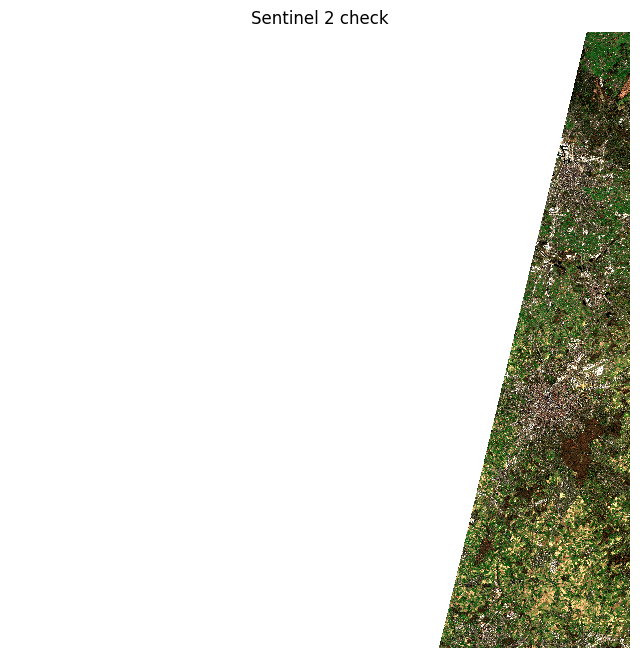

In [348]:
rgb.plot.imshow(figsize=(8, 8), robust=True)
plt.title("Sentinel 2 check")
plt.axis("off")
plt.show()

In [349]:
######################

After some experimentation along the above steps, we selected the following image:

In [350]:
item = items_s2_filtered[0]

In [351]:
item_assets = item.get_assets(media_type=MediaType.ZARR)
##item_assets

In [353]:
cloud_storage = item_assets['product'].href

print('URL for retrieval:',cloud_storage)

URL for retrieval: https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/05/products/cpm_v262/S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521.zarr


In [354]:
dt = xr.open_datatree(
    cloud_storage,
    engine="zarr",
    chunks="auto"
)

In [355]:
for dt_group in sorted(dt.groups):
    print("DataTree group {group_name}".format(group_name=dt_group)) # getting the available groups

DataTree group /
DataTree group /conditions
DataTree group /conditions/geometry
DataTree group /conditions/mask
DataTree group /conditions/mask/detector_footprint
DataTree group /conditions/mask/detector_footprint/r10m
DataTree group /conditions/mask/detector_footprint/r20m
DataTree group /conditions/mask/detector_footprint/r60m
DataTree group /conditions/mask/l1c_classification
DataTree group /conditions/mask/l1c_classification/r60m
DataTree group /conditions/mask/l2a_classification
DataTree group /conditions/mask/l2a_classification/r20m
DataTree group /conditions/mask/l2a_classification/r60m
DataTree group /conditions/meteorology
DataTree group /conditions/meteorology/cams
DataTree group /conditions/meteorology/ecmwf
DataTree group /measurements
DataTree group /measurements/reflectance
DataTree group /measurements/reflectance/r10m
DataTree group /measurements/reflectance/r20m
DataTree group /measurements/reflectance/r60m
DataTree group /quality
DataTree group /quality/atmosphere
Data

In [274]:
# Get /measurements/reflectance/r20m group
# groups = list(dt.groups)
# interesting_groups = [
#     group for group in groups if group.startswith('/measurements/reflectance/r20m')
#     and dt[group].ds.data_vars
# ]
# print(f"\n🔍 Searching for groups with data variables in '/measurements/reflectance/r20m'...")

In [275]:
# if interesting_groups:
#     sample_group = interesting_groups[0]
#     group_ds = dt[sample_group].ds
    
#     print(f"Group '{sample_group}' Information")
#     print("=" * 50)
#     print(f"Dimensions: {dict(group_ds.dims)}")
#     print(f"Data Variables: {list(group_ds.data_vars.keys())}")
#     print(f"Coordinates: {list(group_ds.coords.keys())}")

# else:
#     print("No groups with data variables found in the first 5 groups.")

In [276]:
# Examine the root dataset
# root_dataset = dt.ds

# print("Root Dataset Metadata")

# if root_dataset.attrs:
#     print(f"\nAttributes (first 3):")
#     for key, value in list(root_dataset.attrs.items())[:3]:
#         print(f"   {key}: {str(value)[:80]}{'...' if len(str(value)) > 80 else ''}")

In [326]:
## This did not work
# ## Visualising the RGB quicklook composite:
# ds = dt['quality/l2a_quicklook/r20m'].to_dataset()
# ds_20_ql= ds['tci']

### Computation of NDVI

In [278]:
data = dt ['/measurements/reflectance/r20m'].to_dataset()
data

<xarray.Dataset> Size: 2GB
Dimensions:  (y: 5490, x: 5490)
Coordinates:
  * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
  * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
Data variables:
    b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

In [279]:
red = data['b04']
nir = data['b8a']

In [280]:
sum_bands = nir + red

# zero_mask = (sum_bands == 0) # to avoid 0 division
# sum_bands_z= sum_bands.copy()
# sum_bands_z = da.where(sum_bands_z == 0, 1, sum_bands_z)

diff_bands = nir - red

ndvi = diff_bands / sum_bands

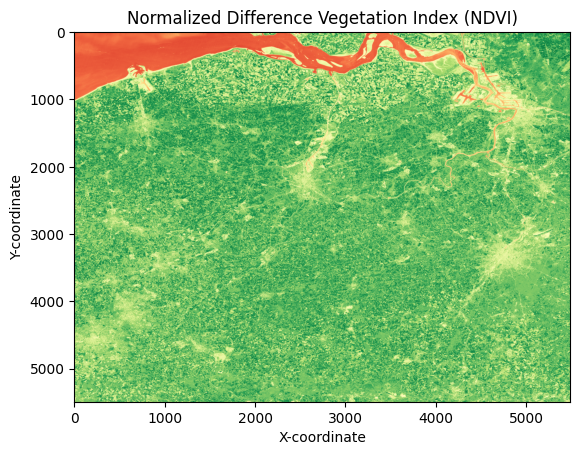

In [281]:
plt.imshow(ndvi,cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(False) # Turn off grid for image plots
plt.axis('tight') # Ensure axes fit the data tightly
# Display the plot
plt.show()

In order to clip the NDVI to the ROI of Brussels, we first need to ensure that Coordinate Systems are the same.

In [282]:
print(f'The CRS for the Brussels area is {gdf.crs}')

The CRS for the Brussels area is EPSG:4326


To retrieve the CRS from the Sentinel 2, there are several options we can do. First, we can use the xxx

Second, we can use the attributes of the xx itself thanks to some "attributes" in the zar file:

## Extracting the Sentinel 3 data (Land Surface Temperature)

In [201]:
eopf_catalog = Client.open(url="https://stac.core.eopf.eodc.eu/")
## eopf_catalog

In [202]:
for collection in eopf_catalog.get_all_collections():
        print(collection.id)

sentinel-2-l2a
sentinel-1-l1-grd
sentinel-3-slstr-l2-lst
sentinel-1-l2-ocn
sentinel-3-slstr-l2-frp
sentinel-3-olci-l2-lfr
sentinel-3-olci-l2-lrr
sentinel-3-olci-l1-efr
sentinel-3-slstr-l1-rbt
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-olci-l1-err


In [230]:
period_lst = "2026-03-01/2026-03-08"

In [231]:
items_s3 = eopf_catalog.search(
    collections= 'sentinel-3-slstr-l2-lst',
    intersects=aoi,
    datetime=period_lst
   ).item_collection()

In [232]:
 print(f'There are {len(items_s3)} items in the collection.')

There are 61 items in the collection.


There are lots of warnings meaning that these images are deprecated and can no longer be used. In order to see what we can use, we print out the first ten items and compare them with the list of those items that had a warning.

In [233]:
for item in items_s3[0:10]:
    print(item)

<Item id=S3B_SL_2_LST____20260308T215338_20260308T215638_20260309T004121_0179_117_286_0720_ESA_O_NR_004>
<Item id=S3B_SL_2_LST____20260308T215338_20260308T215638_20260310T050455_0180_117_286_0720_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260308T205120_20260308T205420_20260308T232520_0179_137_043_0720_PS1_O_NR_004>
<Item id=S3A_SL_2_LST____20260308T205120_20260308T205420_20260310T075919_0180_137_043_0720_PS1_O_NT_004>
<Item id=S3B_SL_2_LST____20260308T102744_20260308T103044_20260308T125734_0179_117_279_1980_ESA_O_NR_004>
<Item id=S3B_SL_2_LST____20260308T102744_20260308T103044_20260309T174051_0179_117_279_1980_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260308T092826_20260308T093126_20260308T114654_0179_137_036_2160_PS1_O_NR_004>
<Item id=S3A_SL_2_LST____20260308T092826_20260308T093126_20260309T203814_0179_137_036_2160_PS1_O_NT_004>
<Item id=S3A_SL_2_LST____20260307T211731_20260307T212031_20260307T235121_0179_137_029_0720_PS1_O_NR_004>
<Item id=S3A_SL_2_LST____20260307T211731_20260307T21203

We also see several things (sentiwiki, page 27):

- **NR versus NT**: NR stands for Near Real Time processing and NT stands for Non-Time critical. We can also see this at the dates of processing. If we take the first and the second items from the list above, where the second file (having NT) is processed at 7 July 2025 while the first file is processed at 30 June 2026.
- **S3A versus S3B**: The S3A and S3B satellites during different times of the day (more below).
In order to understand the data better, let us take one item:


In [234]:
item = items_s3[0]
item

<Item id=S3B_SL_2_LST____20260308T215338_20260308T215638_20260309T004121_0179_117_286_0720_ESA_O_NR_004>

This reveals some interesting results. Under "properties", we can see that "deprecated" is True. Indeed, this file is in the list of deprecated files that appear in our warnings. Because of this expansion, we can also see that we can filter only on the "NT" category. 

If we further want to narrow the search, we can apply two filters:

In [235]:
## Part of script obtained from:
## https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/62_sardinia_s3_lst.html
## and: 
## 
filters = {
    "deprecated":{'eq': False},
    "product:timeliness_category": {'eq':'NT'} 
}
    

Rerun the query:

In [236]:
items_s3 = eopf_catalog.search(
    collections= 'sentinel-3-slstr-l2-lst',
    intersects=aoi,
    query = filters,
    datetime=period_lst
   ).item_collection()

In [237]:
print(f'There are {len(items_s3)} items in the collection.')

There are 30 items in the collection.


In [238]:
for item in items_s3[0:50]:
    print(item)

<Item id=S3B_SL_2_LST____20260308T215338_20260308T215638_20260310T050455_0180_117_286_0720_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260308T205120_20260308T205420_20260310T075919_0180_137_043_0720_PS1_O_NT_004>
<Item id=S3B_SL_2_LST____20260308T102744_20260308T103044_20260309T174051_0179_117_279_1980_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260308T092826_20260308T093126_20260309T203814_0179_137_036_2160_PS1_O_NT_004>
<Item id=S3A_SL_2_LST____20260307T211731_20260307T212031_20260309T085528_0179_137_029_0720_PS1_O_NT_004>
<Item id=S3B_SL_2_LST____20260307T203850_20260307T204150_20260309T034758_0179_117_271_0720_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260307T095437_20260307T095737_20260308T212129_0179_137_022_2160_PS1_O_NT_004>
<Item id=S3A_SL_2_LST____20260306T214343_20260306T214643_20260308T090054_0180_137_015_0720_PS1_O_NT_004>
<Item id=S3B_SL_2_LST____20260306T210501_20260306T210801_20260308T024528_0179_117_257_0720_ESA_O_NT_004>
<Item id=S3A_SL_2_LST____20260306T102048_20260306T10234

In [212]:
## items_s3[0]

In [213]:
## items_s3[-1]

Let's take the first image:

In [88]:
item = items_s3[0]
item

<Item id=S3A_SL_2_LST____20251231T212840_20251231T213140_20260102T092200_0179_134_243_0720_PS1_O_NT_004>

### Basic visualisation

## Now it is your turn

1. Try the above analysis with an **AOI of your choice**. You can either use a Geojson file of your choice. Alternative, you can create a Geojson using the xxx tool. 
2. Play with the **parameters for filtering the Sentinel 2 and Sentinel 3** images such as cloud cover, a different tile, etc.
3. Try to compute **another index** such as a Modified Normalised Difference Water Index (MNDWI). What do you see?

## Next steps

1. **Mosaicing:** In the current code, we only used Sentinel-2 code. In a follow up code, would like to see if one area of interest spans two Sentinel 2 tiles.
2. Create a **median composite** both for the NDVI and LST and this clipped to the AOI.
3. Extract data for **another season** and compare the results.
4. Create a map for **diurnal temperature difference**. You can follow this EOSPF tutorial for 
5. **Overlay the Sentinel 2 data with the Sentinel 3** and do some analytics (e.g. correlation, regression).

## References

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html

https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/62_sardinia_s3_lst.html

https://sentiwiki.copernicus.eu/__attachments/1672112/OMPC.ACR.HBK.002%20-%20Sentinel%203%20SLSTR%20Land%20Handbook%202024%20-%201.4.pdf?inst-v=96021aea-734a-44d2-9ca8-2228c7de7290#:~:text=Land%20surface%20temperature%20products,ice%20and%20inland%20water%20pixels.

https://www.geopythontutorials.com/notebooks/dask_median_composite.html from Ujaval Gandhi

https://stacspec.org/en/tutorials/reading-stac-planetary-computer/

Mapping and Data Visualization with Python Course by Ujaval Gandhi www.spatialthoughts.com

**Regridding**